<h1>1. Carregamento e Inspeção Inicial</h1>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Carregamento do dataset de avaliações turísticas em Recife
df = pd.read_csv(r'D:\Estatistica\avaliacao_turistas_recife (2).csv')

## Avaliação turistica Recife

In [3]:
# primeiras linhas para entender as colunas
df

,ID_Turista,Nacionalidade,Avaliacao_Atrativos,Avaliacao_Hospedagem,Avaliacao_Transporte,Avaliacao_Gastronomia,Dias_Estadia
0,1,França,3,2,4,4,10
1,2,Chile,3,4,1,3,11
2,3,Brasil,4,5,3,3,8
3,4,Colômbia,3,4,1,5,2
4,5,Brasil,5,3,4,4,3
...,...,...,...,...,...,...,...
195,196,França,4,5,4,4,4
196,197,Brasil,5,5,4,5,3
197,198,Colômbia,4,2,4,4,5
198,199,Brasil,5,4,2,5,6


In [4]:
# Verificação de tipos de dados e valores nulos
# O dataset tem 200 linhas e 7 colunas (int64 e object)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ID_Turista             200 non-null    int64 
 1   Nacionalidade          200 non-null    object
 2   Avaliacao_Atrativos    200 non-null    int64 
 3   Avaliacao_Hospedagem   200 non-null    int64 
 4   Avaliacao_Transporte   200 non-null    int64 
 5   Avaliacao_Gastronomia  200 non-null    int64 
 6   Dias_Estadia           200 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 11.1+ KB


<h1>2. Limpeza de Dados (Data Cleaning)</h1>

In [5]:
# 1. Limpa os nomes das colunas (remove espaços invisíveis)
df.columns = df.columns.str.strip()
colunas_notas = ['Avaliacao_Atrativos', 'Avaliacao_Hospedagem', 'Avaliacao_Transporte', 'Avaliacao_Gastronomia']
# Criar uma coluna de 'Média Geral' de satisfação por turista
df['Media_satisfacao'] = df[colunas_notas].mean(axis=1)
# axis =1 A operação é feita horizontalmente (ao longo das colunas), calculando a média para cada linha.

In [6]:
# Visualizando a criação da coluna Media satisfação
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Turista             200 non-null    int64  
 1   Nacionalidade          200 non-null    object 
 2   Avaliacao_Atrativos    200 non-null    int64  
 3   Avaliacao_Hospedagem   200 non-null    int64  
 4   Avaliacao_Transporte   200 non-null    int64  
 5   Avaliacao_Gastronomia  200 non-null    int64  
 6   Dias_Estadia           200 non-null    int64  
 7   Media_satisfacao       200 non-null    float64
dtypes: float64(1), int64(6), object(1)
memory usage: 12.6+ KB


## Análise de Desempenho por Categoria
**Pergunta de Negócio:** Qual dos serviços turísticos em Recife (Atrativos, Hospedagem, Transporte ou Gastronomia) possui a menor nota média e precisa de maior atenção?

> **Hipótese:** O transporte pode ter notas menores devido ao trânsito intenso em horários de pico na região do Marco Zero e Boa Viagem.
3. Engenharia de Atributos (Feature Engineering)
Criação de uma nova métrica para resumir a experiência do turista.

<h3>"Existe uma diferença significativa na satisfação entre turistas brasileiros e estrangeiros?"</h3>

In [7]:
df_media_nacionalidade = df.groupby('Nacionalidade')['Media_satisfacao'].mean().sort_values(ascending=False)
print(df_media_nacionalidade)

Nacionalidade
Itália            3.791667
Uruguai           3.656250
Alemanha          3.638889
Portugal          3.533333
Colômbia          3.531250
Argentina         3.491667
Brasil            3.434375
Chile             3.433333
Espanha           3.400000
Estados Unidos    3.300000
França            3.277778
Name: Media_satisfacao, dtype: float64


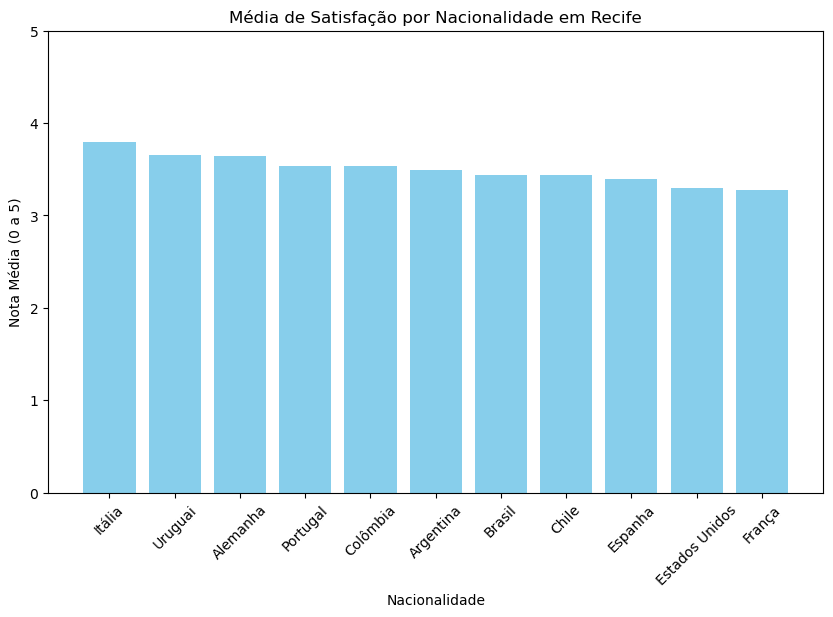

In [8]:
# 1. Definir o tamanho da figura
plt.figure(figsize=(10, 6))

# 2. Criar o gráfico de barras
# .index são os nomes dos países, .values são as médias
plt.bar(df_media_nacionalidade.index, df_media_nacionalidade.values, color='skyblue')

# 3. Adicionar títulos e nomes nos eixos
plt.title('Média de Satisfação por Nacionalidade em Recife')
plt.xlabel('Nacionalidade')
plt.ylabel('Nota Média (0 a 5)')

# 4. Rotacionar os nomes dos países para não ficarem amontoados
plt.xticks(rotation=45)

# 5. Definir o limite do eixo Y para a escala real das notas
plt.ylim(0, 5)

# 6. Exibir o gráfico
plt.show()

<h3>"Turistas que ficam mais tempo."</h3>

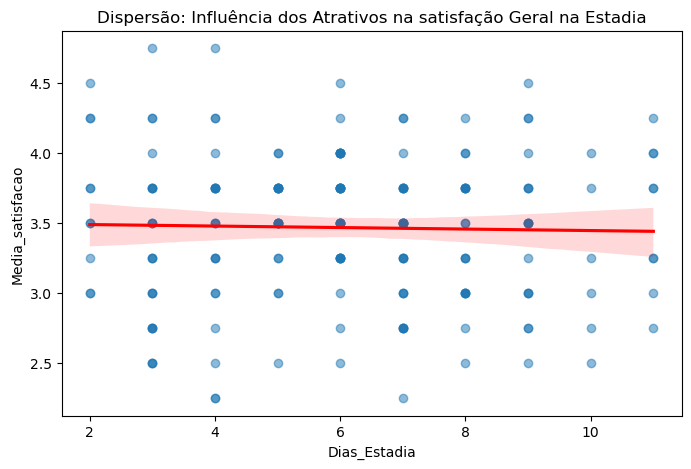

In [9]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Dias_Estadia', y='Media_satisfacao', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Dispersão: Influência dos Atrativos na satisfação Geral na Estadia')
plt.show()

<h2>Através do gráfico de dispersão, observamos que a satisfação média permanece estável, aumenta e diminui conforme o turista estende sua permanência em Recife.</h2>

<h1>O Poder dos Atrativos</h1>

In [10]:
# Correlação
correlacao_valor = df['Avaliacao_Atrativos'].corr(df['Media_satisfacao'])
print(f"A correlação Avaliacao Atrativos e media satisfação é: {correlacao_valor:.2f}")

A correlação Avaliacao Atrativos e media satisfação é: 0.48


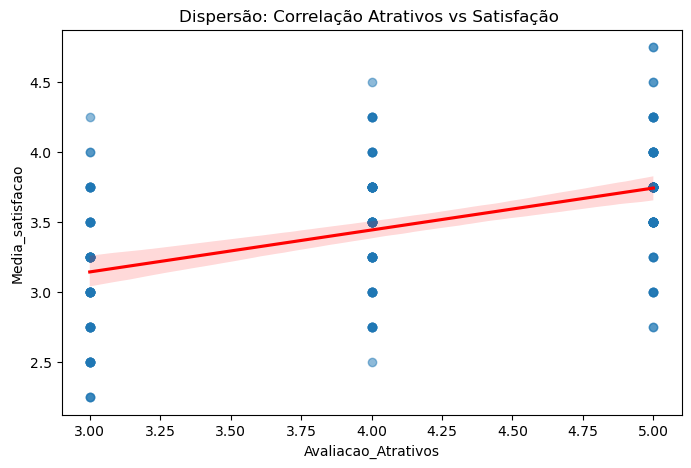

In [11]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Avaliacao_Atrativos', y='Media_satisfacao', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Dispersão: Correlação Atrativos vs Satisfação ')
plt.show()

<h3>Qual a correlação entre a nota de Gastronomia e a nota de Hospedagem?</h3>

In [12]:
# Correlação
correlacao_valor = df['Avaliacao_Hospedagem'].corr(df['Avaliacao_Gastronomia'])
print(f"A correlação entre Hospedagem e Gastronomia é: {correlacao_valor:.2f}")

A correlação entre Hospedagem e Gastronomia é: 0.11


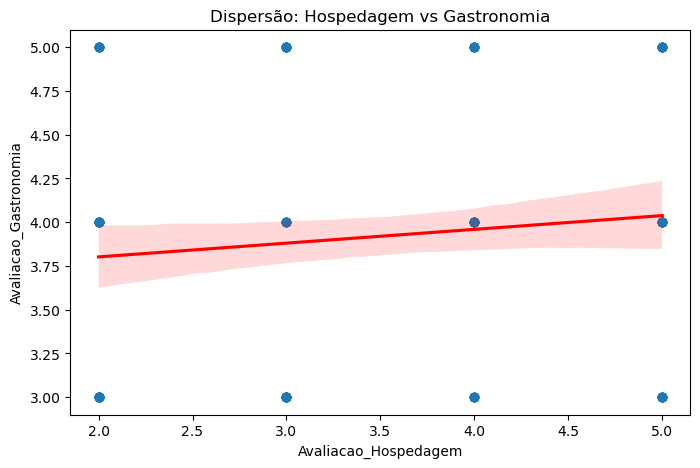

In [13]:

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Avaliacao_Hospedagem', y='Avaliacao_Gastronomia', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Dispersão: Hospedagem vs Gastronomia')
plt.show()

<h3>A satisfação com o hotel não tem nada a ver com a comida (são independentes).</h3>

<h3>A análise demonstra que a qualidade dos pontos turísticos é o motor principal da satisfação em Recife ($r = 0.48$).
Investimentos em infraestrutura turística terão um impacto muito mais direto na nota da cidade do que melhorias isoladas em hotelaria ou transporte.<br>
Conclusão: Isso indica que, para o turista em Recife, a qualidade dos pontos turísticos (como o Recife Antigo ou as praias)
impacta muito mais o seu humor final do que o hotel ou o transporte. Investir na manutenção dos atrativos é a forma mais garantida 
de elevar a nota da cidade.</h3>